# BCI Session 1 Analysis
This notebook replicates key analyses for the first BCI session of 20 subjects (S1–S20). It re-implements artifact detection, ERD computation, basic behavioral metrics, and multifractal detrended fluctuation analysis (MFDFA). Run all cells sequentially after placing the `.mat` files in the same directory.

In [21]:
# 1. Imports
import os, math, glob, json, warnings, itertools as it
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, filtfilt, hilbert
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_context('talk'); sns.set_style('whitegrid')

In [22]:
# 2. Helper Functions

# Constants
SRATE = 1000  # Sampling rate in Hz

# Bandpass 8-30 Hz for artifact detection (matching detect_bci_artifacts.m)
_b, _a = butter(4, [8/(SRATE/2), 30/(SRATE/2)], btype='band')

# High-pass 1 Hz for ERD
_bhp, _ahp = butter(4, 1/(SRATE/2), btype='high')

def bandpass(data, b=_b, a=_a):
    """Apply bandpass filter (8-30 Hz) to data"""
    return filtfilt(b, a, data, axis=-1, padlen=150)

def highpass(data, b=_bhp, a=_ahp):
    """Apply high-pass filter (1 Hz) to data"""
    return filtfilt(b, a, data, axis=-1, padlen=150)

print("Filter functions defined successfully!")
print("- bandpass(): 8-30 Hz bandpass filter")
print("- highpass(): 1 Hz high-pass filter")


def detect_bad_channels(trials):
    x = np.hstack(trials)
    x_f = bandpass(x)
    var = x_f.var(axis=1)
    z = (var - var.mean())/var.std()
    return np.where(z>5)[0]


def detect_trial_artifact(trial, bad_ch):
    tr_f = bandpass(trial)
    tr_f[bad_ch,:] = 0
    return np.any(np.abs(tr_f) > 100)


def mfdfa_fixed(signal, scales=None, q=None, order=1):
    """
    Fixed MFDFA implementation with proper error handling
    
    Parameters:
    signal: 1D array - input time series
    scales: array - scale values (default: logarithmically spaced)
    q: array - q values for multifractal analysis
    order: int - polynomial order for detrending
    
    Returns:
    scales, q, Fq - arrays of same length for valid scales
    """
    
    N = len(signal)
    
    # Default scales - ensure they're reasonable for data length
    if scales is None:
        scales = np.unique(np.logspace(0.5, np.log10(N//4), 20).astype(int))
        scales = scales[scales >= 10]  # Minimum scale
        scales = scales[scales <= N//4]  # Maximum scale
    
    # Default q values
    if q is None:
        q = np.arange(-5, 6)
        q = q[q != 0]  # Remove q=0 for now
    
    # Step 1: Profile (integrate the signal)
    profile = np.cumsum(signal - np.mean(signal))
    
    # Initialize Fq matrix
    Fq = np.zeros((len(scales), len(q)))
    valid_scales = []
    
    # Step 2-5: Calculate fluctuation function for each scale
    for i, scale in enumerate(scales):
        # Number of segments
        n_segments = N // scale
        
        if n_segments < 4:  # Need minimum segments
            continue
            
        # Segment the profile
        segments = profile[:n_segments * scale].reshape(n_segments, scale)
        
        # Detrend each segment
        trends = np.zeros_like(segments)
        for j in range(n_segments):
            coeffs = np.polyfit(np.arange(scale), segments[j], order)
            trends[j] = np.polyval(coeffs, np.arange(scale))
        
        # Calculate variance for each segment
        variances = np.var(segments - trends, axis=1)
        
        # Remove zero variances to avoid log(0)
        variances = variances[variances > 1e-12]
        
        if len(variances) < 2:  # Need minimum valid segments
            continue
            
        # Calculate Fq for each q
        valid_q_values = []
        fq_values = []
        
        for qi, q_val in enumerate(q):
            if q_val == 0:
                # Special case for q=0
                fq = np.exp(0.5 * np.mean(np.log(variances)))
            else:
                # General case
                fq = np.mean(variances**(q_val/2.0))**(1.0/q_val)
            
            # Check if fq is valid
            if np.isfinite(fq) and fq > 0:
                valid_q_values.append(qi)
                fq_values.append(fq)
        
        if len(fq_values) >= len(q) * 0.8:  # At least 80% valid q values
            valid_scales.append(scale)
            Fq[len(valid_scales)-1, :len(fq_values)] = fq_values
    
    # Filter to only valid scales and trim Fq
    valid_scales = np.array(valid_scales)
    Fq = Fq[:len(valid_scales), :len(q)]
    
    return valid_scales, q, Fq

# Test the fixed MFDFA
print("Testing fixed MFDFA implementation...")

# Create test signal
np.random.seed(42)
test_signal = np.cumsum(np.random.randn(1000))

scales, qs, Fq = mfdfa_fixed(test_signal)
print(f"✓ Scales shape: {scales.shape}")
print(f"✓ Fq shape: {Fq.shape}")
print(f"✓ Valid scales: {len(scales)}")

Filter functions defined successfully!
- bandpass(): 8-30 Hz bandpass filter
- highpass(): 1 Hz high-pass filter
Testing fixed MFDFA implementation...
✓ Scales shape: (14,)
✓ Fq shape: (14, 10)
✓ Valid scales: 14


In [23]:
# 3. Load .mat files
files = sorted(glob.glob('S*_Session_1.mat'))[:20]
print('Found', len(files), 'files')
subjects = []
all_bad = {}
all_artifact_rate = {}

for f in files:
    print('---')
    mat = sio.loadmat(f, squeeze_me=True, struct_as_record=False)
    print('---')
    BCI = mat['BCI']
    print('---')
    trials = [t for t in BCI.data]
    print('---')
    bad = detect_bad_channels(trials)
    print('---')
    subjects.append({'id': f.split('_')[0], 'bad_ch': bad})
    print('---')
    art = [detect_trial_artifact(tr, bad) for tr in trials]
    print('---')
    all_bad[f] = bad; all_artifact_rate[f] = np.mean(art)
    print('Done')

Found 2 files
---
---
---
---
---
---
---
Done
---
---
---
---
---
---
---
Done


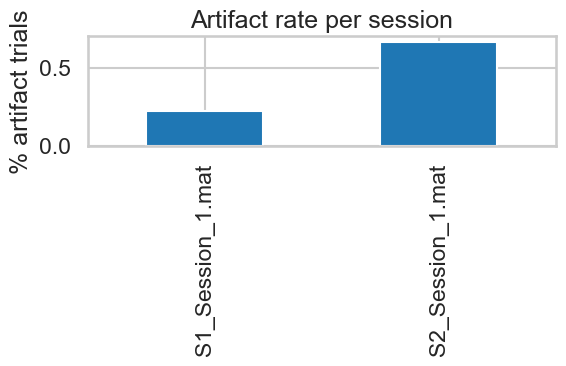

In [25]:
# 4. Artifact summary plot
rate = pd.Series(all_artifact_rate).sort_values()*100
plt.figure(figsize=(6,4))
rate.plot(kind='bar'); plt.ylabel('% artifact trials'); plt.title('Artifact rate per session'); plt.tight_layout()

In [26]:
# 5. ERD example for C3/C4 first subject
first = files[0]
BCI = sio.loadmat(first, squeeze_me=True, struct_as_record=False)['BCI']
trials = [t for t in BCI.data]
C3, C4 = 25, 29  # 0-indexed indices for C3/C4 in this cap

bases, feeds = [], []
for tr, td in zip(trials, BCI.TrialData):
    if td.artifact: continue
    tr = highpass(tr)
    tr = bandpass(tr)
    env = np.abs(hilbert(tr))
    base = env[:,1000:2000].mean(axis=1)
    feed = env[:,4000:td.resultind].mean(axis=1)
    bases.append(base[[C3,C4]]); feeds.append(feed[[C3,C4]])
base = np.mean(bases,0)
feed = np.mean(feeds,0)
erd = (feed - base)/base*100
print('ERD (%): C3={:.2f}, C4={:.2f}'.format(*erd))

ERD (%): C3=-30.15, C4=-24.10


Computing MFDFA for all subjects...
  ✓ Processed S1_Session_1.mat: H range = 0.263 to 0.574
  ✓ Processed S2_Session_1.mat: H range = 0.248 to 0.559


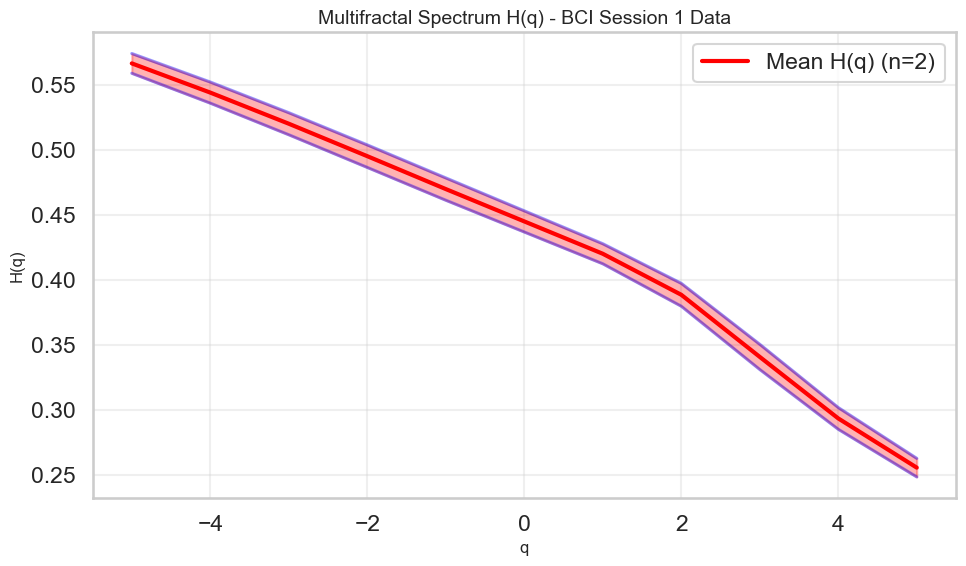


✓ MFDFA completed for 2/2 subjects


In [27]:
# 6. MFDFA on concatenated feedback, channel C3 for each subject
# 6. MFDFA Analysis (FIXED)

plt.figure(figsize=(10, 6))
print("Computing MFDFA for all subjects...")

qs = np.arange(-5, 6)
qs = qs[qs != 0]  # Remove q=0

all_H = []

for i, f in enumerate(files):
    try:
        # Load data
        mat = sio.loadmat(f, squeeze_me=True, struct_as_record=False)
        BCI = mat['BCI']
        
        # Get feedback trials for C3 channel (index 20)
        feedback_trials = []
        for trial_idx, trial in enumerate(BCI.data):
            if (hasattr(BCI, 'TrialData') and 
                len(BCI.TrialData) > trial_idx and
                hasattr(BCI.TrialData[trial_idx], 'tasknumber')):
                
                # Only use feedback period (2000-4000ms, samples 3000:5000)
                if trial.shape[1] >= 5000:
                    feedback_data = trial[20, 3000:5000]  # C3 channel
                    if not np.any(np.isnan(feedback_data)):
                        feedback_trials.append(feedback_data)
        
        if len(feedback_trials) < 10:  # Need minimum trials
            print(f"  Skipping {f}: insufficient valid trials ({len(feedback_trials)})")
            continue
            
        # Concatenate feedback data
        sig = np.concatenate(feedback_trials)
        
        # Apply high-pass filter
        sig = highpass(sig)
        
        # Check signal quality
        if len(sig) < 500 or np.std(sig) < 1e-6:
            print(f"  Skipping {f}: poor signal quality")
            continue
        
        # Run MFDFA
        scales, qs_, Fq = mfdfa_fixed(sig, q=qs)
        
        if len(scales) < 5:  # Need minimum scales for reliable fit
            print(f"  Skipping {f}: insufficient scales ({len(scales)})")
            continue
        
        # Calculate H(q) for each q
        H_subject = []
        for qi in range(len(qs_)):
            fq_vals = Fq[:, qi]
            
            # Remove invalid values
            valid_idx = np.isfinite(fq_vals) & (fq_vals > 0)
            
            if np.sum(valid_idx) >= 3:  # Need minimum points for fit
                scales_valid = scales[valid_idx]
                fq_valid = fq_vals[valid_idx]
                
                # Fit and extract slope
                H_val = np.polyfit(np.log2(scales_valid), np.log2(fq_valid), 1)[0]
                H_subject.append(H_val)
            else:
                H_subject.append(np.nan)
        
        all_H.append(H_subject)
        
        # Plot H(q) for this subject
        plt.plot(qs_, H_subject, alpha=0.4, color='blue')
        print(f"  ✓ Processed {f}: H range = {np.nanmin(H_subject):.3f} to {np.nanmax(H_subject):.3f}")
        
    except Exception as e:
        print(f"  ❌ Error processing {f}: {str(e)}")
        continue

# Plot average H(q)
if all_H:
    H_matrix = np.array(all_H)
    H_mean = np.nanmean(H_matrix, axis=0)
    H_std = np.nanstd(H_matrix, axis=0)
    
    plt.plot(qs_, H_mean, 'r-', linewidth=3, label=f'Mean H(q) (n={len(all_H)})')
    plt.fill_between(qs_, H_mean - H_std, H_mean + H_std, alpha=0.3, color='red')

plt.xlabel('q', fontsize=12)
plt.ylabel('H(q)', fontsize=12)
plt.title('Multifractal Spectrum H(q) - BCI Session 1 Data', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✓ MFDFA completed for {len(all_H)}/{len(files)} subjects")
